# **Libraries**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
import itertools
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, mean_absolute_percentage_error)
from sklearn.inspection import permutation_importance
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam,RMSprop
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Reshape
import torch
import torch.nn as nn

# **1.  Data Understanding and Preprocessing**

## **1.Exploratory Data Analysis**

In [40]:
df3 = pd.read_csv("DATAFILE.csv")
df3.index = df3['date'].tolist()
df3.drop(columns = 'date', inplace = True)

# **DEEP LEARNING MODEL: LSTM**

## **1. Feature selection for LSTM model**

### **Method 1 : Correlation Analysis**

* df3 is only name of data set. **it is a data frame which was created in Feature engineering part**

In [41]:
correlation = df3.corr()["Appliances_imputed"].abs().sort_values(ascending=False)
selected_features = correlation[correlation > 0.1].index
selected_features
top_feature = selected_features.drop('Appliances_imputed')

corr_matrix = df3[top_feature].corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.8)]

X_final = df3[top_feature].drop(columns=to_drop)
final_feature = X_final.columns.tolist()
final_feature.append("Appliances_imputed")
lstm_data = df3[final_feature]
len(lstm_data.columns)

14

In [42]:
# lstm_data.index = lstm_data['Unnamed: 0'].tolist()
# lstm_data.drop(columns=['Unnamed: 0'], inplace=True)

target_column = 'Appliances_imputed'

X = lstm_data.drop(columns=[target_column]).values
y = lstm_data[target_column].values.reshape(-1, 1)

def time_series_split(X, y, train_ratio=0.8):
    split_index = int(len(X) * train_ratio)

    X_train = X[:split_index]
    X_test  = X[split_index:]

    y_train = y[:split_index].reshape(-1, 1)
    y_test  = y[split_index:].reshape(-1, 1)

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = time_series_split(X,y)

feature_scaler = MinMaxScaler()
target_scaler  = MinMaxScaler()

# Fit and transform on training data
X_train = feature_scaler.fit_transform(X_train)
y_train = target_scaler.fit_transform(y_train)

# Only transform on test data
X_test = feature_scaler.transform(X_test)
y_test = target_scaler.transform(y_test)

In [43]:


# --- GPU Check ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)  # allocate memory as needed
        print(f"✅ GPU available: {[gpu.name for gpu in gpus]}")
    except RuntimeError as e:
        print(f"GPU error: {e}")
else:
    print("⚠️ No GPU found — running on CPU")

# --- Run model on GPU if available ---
device = "/GPU:0" if gpus else "/CPU:0"

✅ GPU available: ['/physical_device:GPU:0']


In [44]:
with tf.device(device):
    model1 = Sequential([
        Input(shape=(X_train.shape[1],)),
        Reshape((X_train.shape[1], 1)),
        LSTM(32, return_sequences=True, kernel_regularizer=l2(0.001)),
        Dropout(0.3),
        LSTM(16, return_sequences=True, kernel_regularizer=l2(0.001)),
        Dropout(0.3),
        LSTM(8, return_sequences=False, kernel_regularizer=l2(0.001)),
        Dropout(0.3),
        Dense(1)
    ])

    model1.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["mae"])

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
        ModelCheckpoint("best_model.keras", monitor="val_loss", save_best_only=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-6),
    ]

    history = model1.fit(
        X_train, y_train,
        epochs=25,
        batch_size=5,
        validation_split=0.2,
        callbacks=callbacks,
        verbose=1,
        shuffle=False
    )

    y_pred_scaled = model1.predict(X_test)

test_loss, test_mae = model1.evaluate(X_test, y_test)
test_loss, test_mae

Epoch 1/25
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - loss: 0.0426 - mae: 0.1344 - val_loss: 0.0209 - val_mae: 0.0972 - learning_rate: 0.0010
Epoch 2/25
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 38s 17ms/step - loss: 0.0226 - mae: 0.1063 - val_loss: 0.0190 - val_mae: 0.0953 - learning_rate: 0.0010
Epoch 3/25
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 0.0207 - mae: 0.1033 - val_loss: 0.0175 - val_mae: 0.0916 - learning_rate: 0.0010
Epoch 4/25
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 0.0178 - mae: 0.0955 - val_loss: 0.0158 - val_mae: 0.0864 - learning_rate: 0.0010
Epoch 5/25
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - loss: 0.0168 - mae: 0.0927 - val_loss: 0.0149 - val_mae: 0.0837 - learning_rate: 0.0010
Epoch 6/25
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 0.0165 - mae: 0.0917 - val_loss: 0.0144 - val_mae: 0.0829 - learning_rate: 0.0010
Epoch 7/25
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 0.0160 - mae: 0.0901 - val_loss: 0.0130 - val_mae: 0.0778 - 

(0.010948477312922478, 0.0726819783449173)

In [45]:
with tf.device(device):
    model2 = Sequential([
        Input(shape=(X_train.shape[1],)),
        Reshape((X_train.shape[1], 1)),
        LSTM(32, return_sequences=True),
        Dropout(0.3),
        LSTM(16, return_sequences=True),
        Dropout(0.3),
        LSTM(8, return_sequences=False),
        Dropout(0.3),
        Dense(1)
    ])

    model2.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["mae"])

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
        ModelCheckpoint("best_model.keras", monitor="val_loss", save_best_only=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-6),
    ]

    history = model2.fit(
        X_train, y_train,
        epochs=25,
        batch_size=16,
        validation_split=0.2,
        callbacks=callbacks,
        verbose=1,
        shuffle=False
    )

    y_pred_scaled = model2.predict(X_test)


test_loss, test_mae = model2.evaluate(X_test, y_test)
test_loss, test_mae

Epoch 1/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0362 - mae: 0.1428 - val_loss: 0.0175 - val_mae: 0.0989 - learning_rate: 0.0010
Epoch 2/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0244 - mae: 0.1149 - val_loss: 0.0148 - val_mae: 0.0884 - learning_rate: 0.0010
Epoch 3/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0215 - mae: 0.1084 - val_loss: 0.0152 - val_mae: 0.0884 - learning_rate: 0.0010
Epoch 4/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0195 - mae: 0.1024 - val_loss: 0.0147 - val_mae: 0.0870 - learning_rate: 0.0010
Epoch 5/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.0184 - mae: 0.0999 - val_loss: 0.0141 - val_mae: 0.0851 - learning_rate: 0.0010
Epoch 6/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0172 - mae: 0.0970 - val_loss: 0.0134 - val_mae: 0.0826 - learning_rate: 0.0010
Epoch 7/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0169 - mae: 0.0958 - val_loss: 0.0133 - val_mae: 0.0824 - learning_rate: 0.0010

(0.012377987615764141, 0.07930801808834076)

In [46]:
with tf.device(device):
    model4 = Sequential([
        Input(shape=(X_train.shape[1],)),
        Reshape((X_train.shape[1], 1)),
        LSTM(32, return_sequences=True, activation='relu'),
        Dropout(0.3),
        LSTM(16, return_sequences=True, activation='relu'),
        Dropout(0.3),
        LSTM(8, return_sequences=False, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='relu')
    ])

    model4.compile(optimizer=RMSprop(learning_rate=0.001), loss="mse", metrics=["mae"])

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
        ModelCheckpoint("best_model.keras", monitor="val_loss", save_best_only=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-6),
    ]

    history = model4.fit(
        X_train, y_train,
        epochs=25,
        batch_size=16,
        validation_split=0.2,
        callbacks=callbacks,
        verbose=1,
        shuffle=False
    )

    y_pred_scaled = model4.predict(X_test)

test_loss, test_mae = model4.evaluate(X_test, y_test)
test_loss, test_mae



Epoch 1/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - loss: 0.0457 - mae: 0.1617 - val_loss: 0.0280 - val_mae: 0.1202 - learning_rate: 0.0010
Epoch 2/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0285 - mae: 0.1212 - val_loss: 0.0212 - val_mae: 0.1058 - learning_rate: 0.0010
Epoch 3/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0227 - mae: 0.1084 - val_loss: 0.0166 - val_mae: 0.0958 - learning_rate: 0.0010
Epoch 4/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0197 - mae: 0.1019 - val_loss: 0.0153 - val_mae: 0.0918 - learning_rate: 0.0010
Epoch 5/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0182 - mae: 0.0983 - val_loss: 0.0139 - val_mae: 0.0873 - learning_rate: 0.0010
Epoch 6/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0165 - mae: 0.0936 - val_loss: 0.0117 - val_mae: 0.0790 - learning_rate: 0.0010
Epoch 7/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0161 - mae: 0.0921 - val_loss: 0.0110 - val_mae: 0.0771 - learning_rate: 0.0010
Epoc

(0.010769465006887913, 0.07519882172346115)

In [47]:

with tf.device(device):
    model5 = Sequential([
        Input(shape=(X_train.shape[1],)),
        Reshape((X_train.shape[1], 1)),
        LSTM(32, return_sequences=True),
        Dropout(0.3),
        LSTM(16, return_sequences=True),
        Dropout(0.3),
        LSTM(8, return_sequences=True),
        Dropout(0.3),
        LSTM(4, return_sequences=False),
        Dropout(0.3),
        Dense(1, activation='relu')
    ])

    model5.compile(optimizer=RMSprop(learning_rate=0.001), loss="mse", metrics=["mae"])

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
        ModelCheckpoint("best_model.keras", monitor="val_loss", save_best_only=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-6),
    ]

    history = model5.fit(
        X_train, y_train,
        epochs=25,
        batch_size=16,
        validation_split=0.2,
        callbacks=callbacks,
        verbose=1,
        shuffle=False  # ← typo fixed
    )

    y_pred_scaled = model5.predict(X_test)

test_loss, test_mae = model5.evaluate(X_test, y_test)
test_loss, test_mae


Epoch 1/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0399 - mae: 0.1489 - val_loss: 0.0213 - val_mae: 0.1086 - learning_rate: 0.0010
Epoch 2/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0260 - mae: 0.1171 - val_loss: 0.0176 - val_mae: 0.0975 - learning_rate: 0.0010
Epoch 3/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.0223 - mae: 0.1097 - val_loss: 0.0183 - val_mae: 0.0973 - learning_rate: 0.0010
Epoch 4/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.0208 - mae: 0.1062 - val_loss: 0.0198 - val_mae: 0.1008 - learning_rate: 0.0010
Epoch 5/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0203 - mae: 0.1057 - val_loss: 0.0177 - val_mae: 0.0949 - learning_rate: 0.0010
Epoch 6/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0195 - mae: 0.1032 - val_loss: 0.0166 - val_mae: 0.0917 - learning_rate: 0.0010
Epoch 7/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0186 - mae: 0.1008 - val_loss: 0.0148 - val_mae: 0.0872 - learning_rate: 0.001

(0.011110331863164902, 0.07551522552967072)

In [48]:
with tf.device(device):
    model6 = Sequential([
        Input(shape=(X_train.shape[1],)),
        Reshape((X_train.shape[1], 1)),
        LSTM(64, return_sequences=True),
        Dropout(0.3),
        LSTM(32, return_sequences=True),
        Dropout(0.3),
        LSTM(16, return_sequences=True),
        Dropout(0.3),
        Dense(1)
    ])

    model6.compile(optimizer=RMSprop(learning_rate=0.001), loss="mse", metrics=["mae"])

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
        ModelCheckpoint("best_model.keras", monitor="val_loss", save_best_only=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-6),
    ]

    history = model6.fit(
        X_train, y_train,
        epochs=25,
        batch_size=16,
        validation_split=0.2,
        callbacks=callbacks,
        verbose=1,
        shuffle=False  # ← typo fixed
    )

    y_pred_scaled = model6.predict(X_test)

test_loss, test_mae = model6.evaluate(X_test, y_test)
test_loss, test_mae


Epoch 1/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0408 - mae: 0.1499 - val_loss: 0.0266 - val_mae: 0.1212 - learning_rate: 0.0010
Epoch 2/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0296 - mae: 0.1283 - val_loss: 0.0240 - val_mae: 0.1173 - learning_rate: 0.0010
Epoch 3/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0281 - mae: 0.1258 - val_loss: 0.0232 - val_mae: 0.1163 - learning_rate: 0.0010
Epoch 4/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0273 - mae: 0.1245 - val_loss: 0.0225 - val_mae: 0.1149 - learning_rate: 0.0010
Epoch 5/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0263 - mae: 0.1223 - val_loss: 0.0207 - val_mae: 0.1099 - learning_rate: 0.0010
Epoch 6/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0239 - mae: 0.1160 - val_loss: 0.0184 - val_mae: 0.1016 - learning_rate: 0.0010
Epoch 7/25
696/696 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0206 - mae: 0.1068 - val_loss: 0.0168 - val_mae: 0.0959 - learning_rate: 0.0010
E

(0.010278841480612755, 0.07243027538061142)

* ALL models are better than Random forest model
* Best one : model6

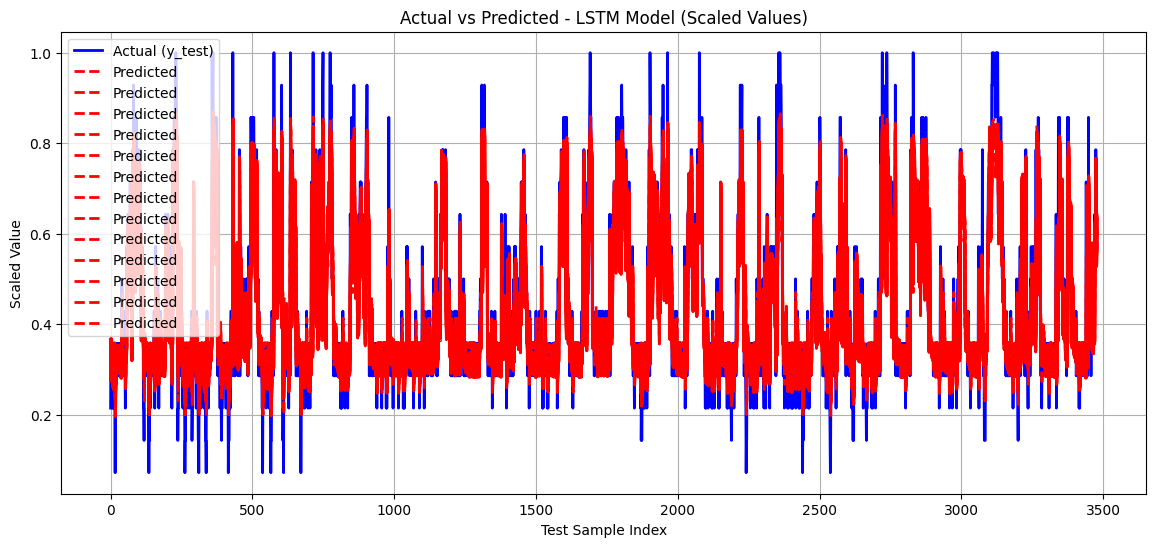

In [60]:


y_test_plot = np.squeeze(y_test)
y_pred_plot = np.squeeze(y_pred_scaled)

plt.figure(figsize=(14, 6))

plt.plot(y_test_plot, 'b-', linewidth=2, label='Actual (y_test)')
plt.plot(y_pred_plot, 'r--', linewidth=2, label='Predicted')

plt.title('Actual vs Predicted - LSTM Model (Scaled Values)')
plt.xlabel('Test Sample Index')
plt.ylabel('Scaled Value')
plt.legend()
plt.grid(True)
plt.show()

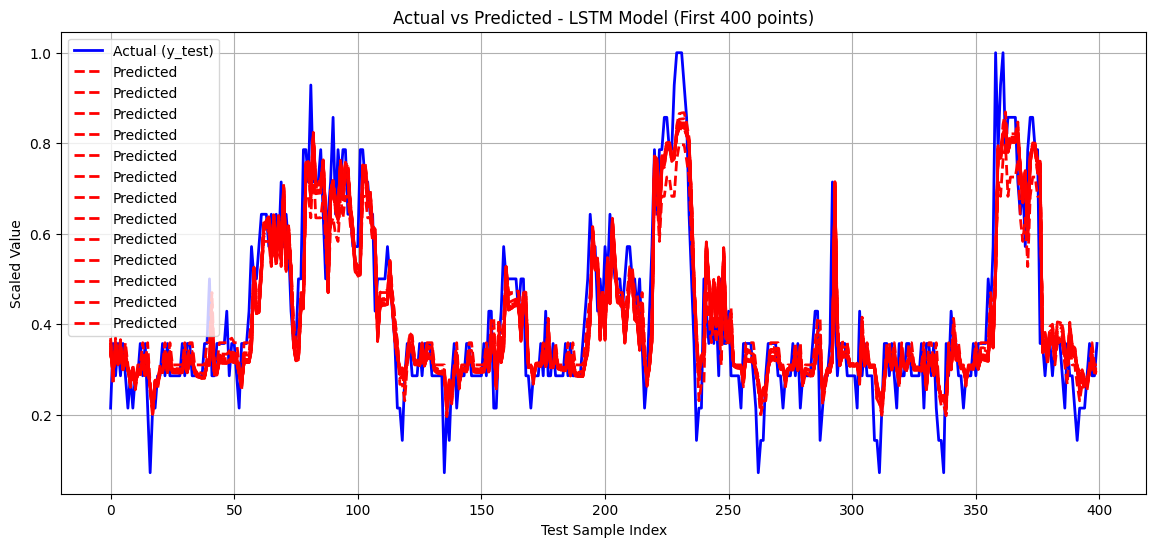

In [61]:
n = 400

plt.figure(figsize=(14, 6))
plt.plot(y_test_plot[:n], label='Actual (y_test)', color='blue', linewidth=2)
plt.plot(y_pred_plot[:n], label='Predicted', color='red', linestyle='--', linewidth=2)

plt.title('Actual vs Predicted - LSTM Model (First 400 points)')
plt.xlabel('Test Sample Index')
plt.ylabel('Scaled Value')
plt.legend()
plt.grid(True)
plt.show()

# Save the model

In [62]:
model6.save("lstm_model6.keras")